<a href="https://colab.research.google.com/github/madhankumar003/HTIC_Practice_codes/blob/main/Day_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Median Filter**

Image filtered using our scratch-built Median filter:


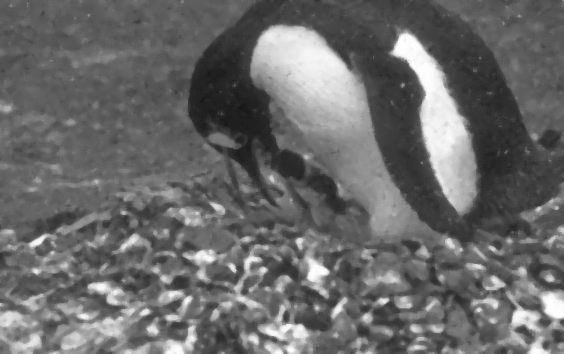

In [ ]:
import numpy as np
import cv2
from google.colab.patches import cv2_imshow

def apply_median_filter_from_scratch(image, size=3):
    """Step 3: Slide the window across the image pixels (Sorting)"""
    h, w = image.shape
    k = size // 2

    output = np.zeros((h, w), dtype=np.float32)

    # Pad the image edges just like the Gaussian code to handle corners
    padded_image = np.pad(image, k, mode='edge')

    for i in range(h):
        for j in range(w):
            # Extract the neighborhood region (e.g., a 3x3 or 5x5 grid)
            region = padded_image[i:i + size, j:j + size]

            # Flatten the 2D grid into a 1D line of numbers
            flat_region = region.flatten()

            # Sort the line from smallest to largest
            sorted_region = np.sort(flat_region)

            # Pick the exact middle value (this ignores the extreme 0 or 255 noise)
            middle_index = len(sorted_region) // 2
            new_value = sorted_region[middle_index]

            # Place that middle value into the output image
            output[i, j] = new_value

    return output.astype(np.uint8)


# Load the image and convert to grayscale
image = cv2.imread("my_picture.jpg")
gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# Apply our manual median filter (size 5 is standard for salt-and-pepper)
custom_filtered = apply_median_filter_from_scratch(gray_image, size=5)

print("Image filtered using our scratch-built Median filter:")
cv2_imshow(custom_filtered)

**Adaptive filter**

converted gray pixel value
[[240 240 241 ... 255 255 255]
 [240 240 241 ... 255 255 255]
 [240 240 241 ... 255 255 255]
 ...
 [255 255 255 ...  87 105 100]
 [255 255 255 ...  94 111 122]
 [253 255 255 ...  88  98  99]]
padded image
[[240 240 240 ... 255 255 255]
 [240 240 240 ... 255 255 255]
 [240 240 240 ... 255 255 255]
 ...
 [253 253 253 ...  99  99  99]
 [253 253 253 ...  99  99  99]
 [253 253 253 ...  99  99  99]]
output
[[240.19994  240.39981  240.60019  ... 255.       255.       255.      ]
 [240.19994  240.39981  240.60019  ... 255.       255.       255.      ]
 [240.19994  240.39981  240.60019  ... 255.       255.       255.      ]
 ...
 [254.52046  254.56056  254.24258  ...  90.17369   96.689354  96.5933  ]
 [254.40086  254.60045  254.32214  ...  93.78561   99.742546 104.1947  ]
 [254.27765  254.5207   254.20268  ...  92.80926   97.53415  100.25422 ]]
Image filtered using our scratch-built Adaptive filter:


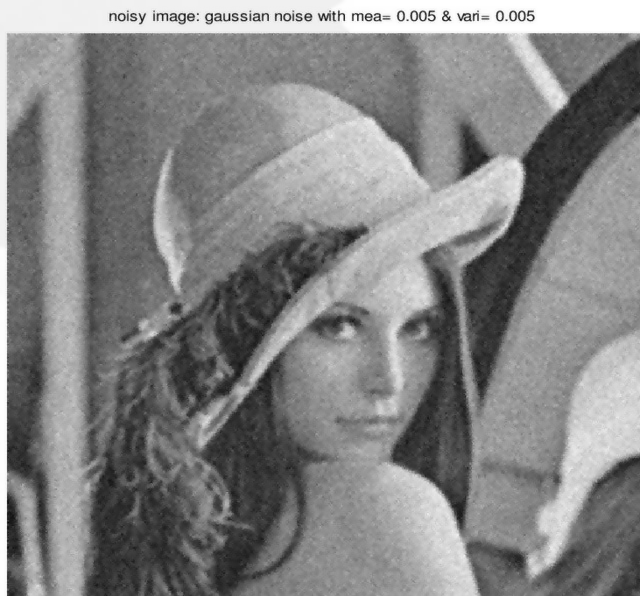

In [2]:
import numpy as np
import cv2
from google.colab.patches import cv2_imshow

def apply_adaptive_filter_from_scratch(image, size=3, noise_variance=500):
    """Step 3: Slide the window and dynamically adapt based on local variance"""
    h, w = image.shape
    k = size // 2

    output = np.zeros((h, w), dtype=np.float32)

    # Pad the image edges just like the Gaussian and Median filters
    padded_image = np.pad(image, k, mode='edge')
    print("padded image")
    print(padded_image)
    for i in range(h):
        for j in range(w):
            # Extract the neighborhood region (e.g., a 3x3 or 5x5 grid)
            region = padded_image[i:i + size, j:j + size]

            # The specific center pixel we are trying to fix
            center_pixel = padded_image[i + k, j + k]

            # 1. Calculate Local Statistics for this specific window
            local_mean = np.mean(region)
            local_var = np.var(region)

            # 2. Make the Dynamic Decision (Calculate the Adaptive Weight)
            # If local_var is high (an edge), weight becomes close to 1
            # If local_var is low (flat noise), weight becomes close to 0
            # (We add 1e-5 just to prevent a 'divide by zero' crash in Python)
            weight = local_var / (local_var + noise_variance + 1e-5)

            # 3. Calculate the new pixel value
            # Formula: Blended Average + Weight * (Original Pixel - Average)
            new_value = local_mean + weight * (center_pixel - local_mean)

            # Place that calculated value into the output image
            output[i, j] = new_value
    print("output")
    print(output)
    return output.astype(np.uint8)


# Load the image and convert to grayscale
image = cv2.imread("my_picture1.jpg")
gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
print("converted gray pixel value")
print(gray_image)
# Apply our manual adaptive filter
# 'noise_variance' is our manual guess of how much overall Poisson noise is in the photo
custom_filtered = apply_adaptive_filter_from_scratch(gray_image, size=5, noise_variance=500)

print("Image filtered using our scratch-built Adaptive filter:")
cv2_imshow(custom_filtered)